In [32]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , r2_score

In [33]:
df = pd.read_csv("salary.csv")

In [34]:
df

,Experience_years,Salary_lpa
0,0.5,3.0
1,1.0,3.5
2,2.0,4.5
3,3.0,5.2
4,4.0,6.0
5,5.0,6.8
6,6.0,7.5
7,7.0,8.2
8,8.0,9.0
9,10.0,10.5


In [35]:
X = df[['Experience_years']]
Y = df['Salary_lpa']

In [36]:
x_train , x_test , y_train , y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state = 42
) 

In [37]:
# using linear regression model

model = LinearRegression()
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
print("\nSlope (m) : " , model.coef_[0])
print("Intercept (b) : " , model.intercept_)


Slope (m) :  0.762312925170068
Intercept (b) :  2.8900680272108845


In [39]:
y_pred = model.predict(x_test)

print("\nActual vs Predicted: ")
for actual , pred  in zip(y_test , y_pred):
    print(f"Actual: {actual:.2f} , Predicted: {pred:.2f}")


Actual vs Predicted: 
Actual: 6.80 , Predicted: 6.70
Actual: 3.00 , Predicted: 3.27
Actual: 10.50 , Predicted: 10.51


In [40]:
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("\nMean Absolute Error : " , mae)
print("R2 Score : " , r2)


Mean Absolute Error :  0.1275963718820865
R2 Score :  0.9970343792256637


In [41]:
new_salary = np.array([[15]])
predicted_salary = model.predict(new_salary)

print(f"\nPredicted Salary for 18 year Experienced Years : {predicted_salary[0]:.2f} lakhs")


Predicted Salary for 18 year Experienced Years : 14.32 lakhs


C:\Users\naina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


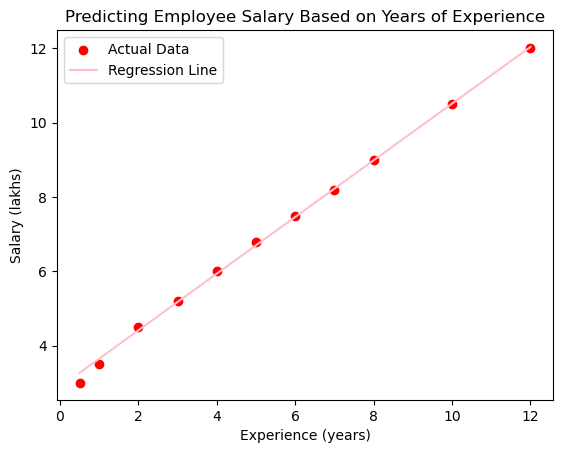

In [42]:
plt.scatter(X , Y , color = "red" , label = "Actual Data")
plt.plot(X , model.predict(X) , color = "pink" ,  label = "Regression Line")
plt.xlabel("Experience (years)")
plt.ylabel("Salary (lakhs)")
plt.title("Predicting Employee Salary Based on Years of Experience")
plt.legend()
plt.show()